In [1]:
import tensorflow as tf
import keras
from keras import layers
import pickle
import numpy as np
import pandas as pd
from keras.models import load_model

from scipy.stats import norm
from scipy import stats
import matplotlib.pyplot as plt
from scipy.stats import ks_2samp, anderson, wasserstein_distance
from sklearn.metrics import r2_score
import glob

import warnings
warnings.filterwarnings("ignore")

In [2]:
lat = np.arange(-90, 90, 180/192)
lon = np.arange(0, 360, 360/288)

lat_bnd1 = np.where(lat==10.3125)[0][0]
lat_bnd2 = np.where(lat==50.625)[0][0]
lon_bnd1 = np.where(lon==210)[0][0]
lon_bnd2 = np.where(lon==300)[0][0]

In [3]:
## ERA5 Data

In [4]:
#set the base path 
base_path = '/sfs/weka/scratch/zkq5md'

#load the dataframe
df_se_era5 = pd.read_csv(f'{base_path}/Data/ERA5/Final/SE_detrend_precip.csv', index_col='Unnamed: 0')
df_gp_era5 = pd.read_csv(f'{base_path}/Data/ERA5/Final/GP_detrend_precip.csv', index_col='Unnamed: 0')
df_ca_era5 = pd.read_csv(f'{base_path}/Data/ERA5/Final/CA_detrend_precip.csv', index_col='Unnamed: 0')
df_se_era5

,Datetimes,Maximum Precipitation,lats,lons
0,1950-01-01,29.729749,32.8125,266.25
1,1950-01-02,39.121912,35.6250,270.00
2,1950-01-03,18.399313,35.6250,266.25
3,1950-01-04,59.563390,35.6250,267.50
4,1950-01-05,40.699897,35.6250,271.25
...,...,...,...,...
9977,2015-12-27,75.272000,34.6875,266.25
9978,2015-12-28,51.817838,35.6250,267.50
9979,2015-12-29,26.021470,34.6875,276.25
9980,2015-12-30,44.338429,30.9375,271.25


In [5]:
with open(f'{base_path}/Data/ERA5/Final/X_era5.pkl', "rb") as f:
    x = pickle.load(f)
    
x = np.transpose(np.array(x), (0, 2, 3, 1))

x = x[:, lat_bnd1:lat_bnd2, lon_bnd1:lon_bnd2, :]

x_test_era5 = x[8000:]

y_se_era5_test = df_se_era5['Maximum Precipitation'].values[8000:]
y_gp_era5_test = df_gp_era5['Maximum Precipitation'].values[8000:]
y_ca_era5_test = df_ca_era5['Maximum Precipitation'].values[8000:]



In [6]:
polyfit_se = pd.read_csv(f'{base_path}/Data/ERA5/Final/SE_poltfit.csv', index_col='Unnamed: 0')
polyfit_gp = pd.read_csv(f'{base_path}/Data/ERA5/Final/GP_poltfit.csv', index_col='Unnamed: 0')
polyfit_ca = pd.read_csv(f'{base_path}/Data/ERA5/Final/CA_poltfit.csv', index_col='Unnamed: 0')

In [7]:
## CESM2-LE

In [8]:
#set the base path 
base_path = '/sfs/weka/scratch/zkq5md'

with open(f"{base_path}/Full_Domain/X_test.pkl", "rb") as f:
    x_test_cesm = pickle.load(f)
    
x_test_cesm = x_test_cesm[:, lat_bnd1:lat_bnd2, lon_bnd1:lon_bnd2, :]
    
print(x_test_cesm.shape)

(22652, 43, 72, 3)


In [9]:
#the set the validata and testing members
val_num = 15
test_num = val_num +2

#set the range of member numbers
val_nums = np.arange(val_num,val_num+2,1)
test_nums = np.arange(test_num,test_num+2,1)

In [10]:
#load the dataframe
df_se_cesm = pd.read_csv(f'{base_path}/Full_Domain/SE_detrend_precip.csv', index_col='Unnamed: 0')
df_gp_cesm = pd.read_csv(f'{base_path}/Full_Domain/GP_detrend_precip.csv', index_col='Unnamed: 0')
df_ca_cesm = pd.read_csv(f'{base_path}/Full_Domain/CA_detrend_precip.csv', index_col='Unnamed: 0')

df_se_cesm=df_se_cesm[(df_se_cesm['Member'].isin(test_nums))].copy()
df_gp_cesm=df_gp_cesm[(df_gp_cesm['Member'].isin(test_nums))].copy()
df_ca_cesm=df_ca_cesm[(df_ca_cesm['Member'].isin(test_nums))].copy()

y_se_cesm_test = df_se_cesm['Maximum Precipitation'].values
y_gp_cesm_test = df_gp_cesm['Maximum Precipitation'].values
y_ca_cesm_test = df_ca_cesm['Maximum Precipitation'].values

df_se_cesm

,Datetimes,Member,Maximum Precipitation,lats,lons
181216,1940-01-01 00:00:00,17.0,46.601204,30.628272,280.00
181217,1940-01-02 00:00:00,17.0,8.604802,35.340314,278.75
181218,1940-01-03 00:00:00,17.0,53.491662,35.340314,276.25
181219,1940-01-04 00:00:00,17.0,41.651847,35.340314,276.25
181220,1940-01-05 00:00:00,17.0,16.084387,35.340314,276.25
...,...,...,...,...,...
203863,2014-12-28 00:00:00,18.0,12.462667,35.340314,266.25
203864,2014-12-29 00:00:00,18.0,9.678012,35.340314,272.50
203865,2014-12-30 00:00:00,18.0,39.065999,34.397906,277.50
203866,2014-12-31 00:00:00,18.0,18.523190,35.340314,280.00


In [11]:
se_polyfit = pd.read_csv(f'{base_path}/Full_Domain/SE_polyfit_slope_int.csv', index_col='Unnamed: 0')
gp_polyfit = pd.read_csv(f'{base_path}/Full_Domain/GP_polyfit_slope_int.csv', index_col='Unnamed: 0')
ca_polyfit = pd.read_csv(f'{base_path}/Full_Domain/CA_polyfit_slope_int.csv', index_col='Unnamed: 0')

In [12]:
locs = ['se', 'gp', 'ca']
dirs = ['pre', 'pre', 'post', 'brute']
datasets = ['cesm', 'era5', 'era5', 'era5']
model_types = ['mse', 'weight_mse', 'weight_mae', 'line']

rss = []
locss = []
dirss = []
datass = []
typess = []


for num1, direct in enumerate(dirs):
    
    for loc in locs:
        
        for model_type in model_types:
            
            model_list = glob.glob(f'{base_path}/Data/ERA5/models/trans_learn/{direct}/{loc}_max_precip_{model_type}_model*')
            rs = []
            
            for model_path in model_list:
                
                if model_type == 'weight_mse' or model_type == 'line':
                    model = load_model(f"{model_path}", compile=False)
                    
                else:
                    model = load_model(f"{model_path}", safe_mode=False)
                    
                y_pred = model.predict(locals()[f'x_test_{datasets[num1]}'])
                rs.append(r2_score(locals()[f'y_{loc}_{datasets[num1]}_test'], y_pred))
                
            rss.append(np.average(rs))
            locss.append(loc)
            dirss.append(direct)
            datass.append(datasets[num1])
            typess.append(model_type)
                    


I0000 00:00:1764553637.962199  263136 service.cc:146] XLA service 0x7f9614008500 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764553637.962232  263136 service.cc:154]   StreamExecutor device (0): Host, Default Version


  5/708 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step   

I0000 00:00:1764553638.542157  263136 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


708/708 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 12s 17ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 13

Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/IPython/core/interactiveshell.py", line 3577, in run_code
  File "/tmp/ipykernel_262870/2232555152.py", line 30, in <module>
    y_pred = model.predict(locals()[f'x_test_{datasets[num1]}'])
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.12/dist-packages/keras/src/utils/traceback_utils.py", line 117, in error_handler
  File "/usr/local/lib/python3.12/dist-packages/keras/src/backend/tensorflow/trainer.py", line 510, in predict
  File "/usr/local/lib/python3.12/dist-packages/keras/src/tree/tree_api.py", line 177, in map_structure_up_to
  File "/usr/local/lib/python3.12/dist-packages/keras/src/tree/optree_impl.py", line 85, in map_structure_up_to
  File "/usr/local/lib/python3.12/dist-packages/keras/src/tree/optree_impl.py", line 252, in _map_structure_with_path_up_to
  File "/usr/local/lib/python3.12/dist-packages/keras/src/tree/optree_impl.py", line 87, in <

In [13]:
df = pd.DataFrame({'r2': rss, 'location': locss, 'directory': dirss,
              'dataset': datass, 'model type': typess})
df

,r2,location,directory,dataset,model type
0,0.870106,se,pre,cesm,mse
1,0.830473,se,pre,cesm,weight_mse
2,0.865498,se,pre,cesm,weight_mae
3,0.657318,se,pre,cesm,line
4,0.834808,gp,pre,cesm,mse
5,0.788297,gp,pre,cesm,weight_mse
6,0.829549,gp,pre,cesm,weight_mae
7,0.539340,gp,pre,cesm,line
8,0.900132,ca,pre,cesm,mse
9,0.862838,ca,pre,cesm,weight_mse


(0.0, 1.1)

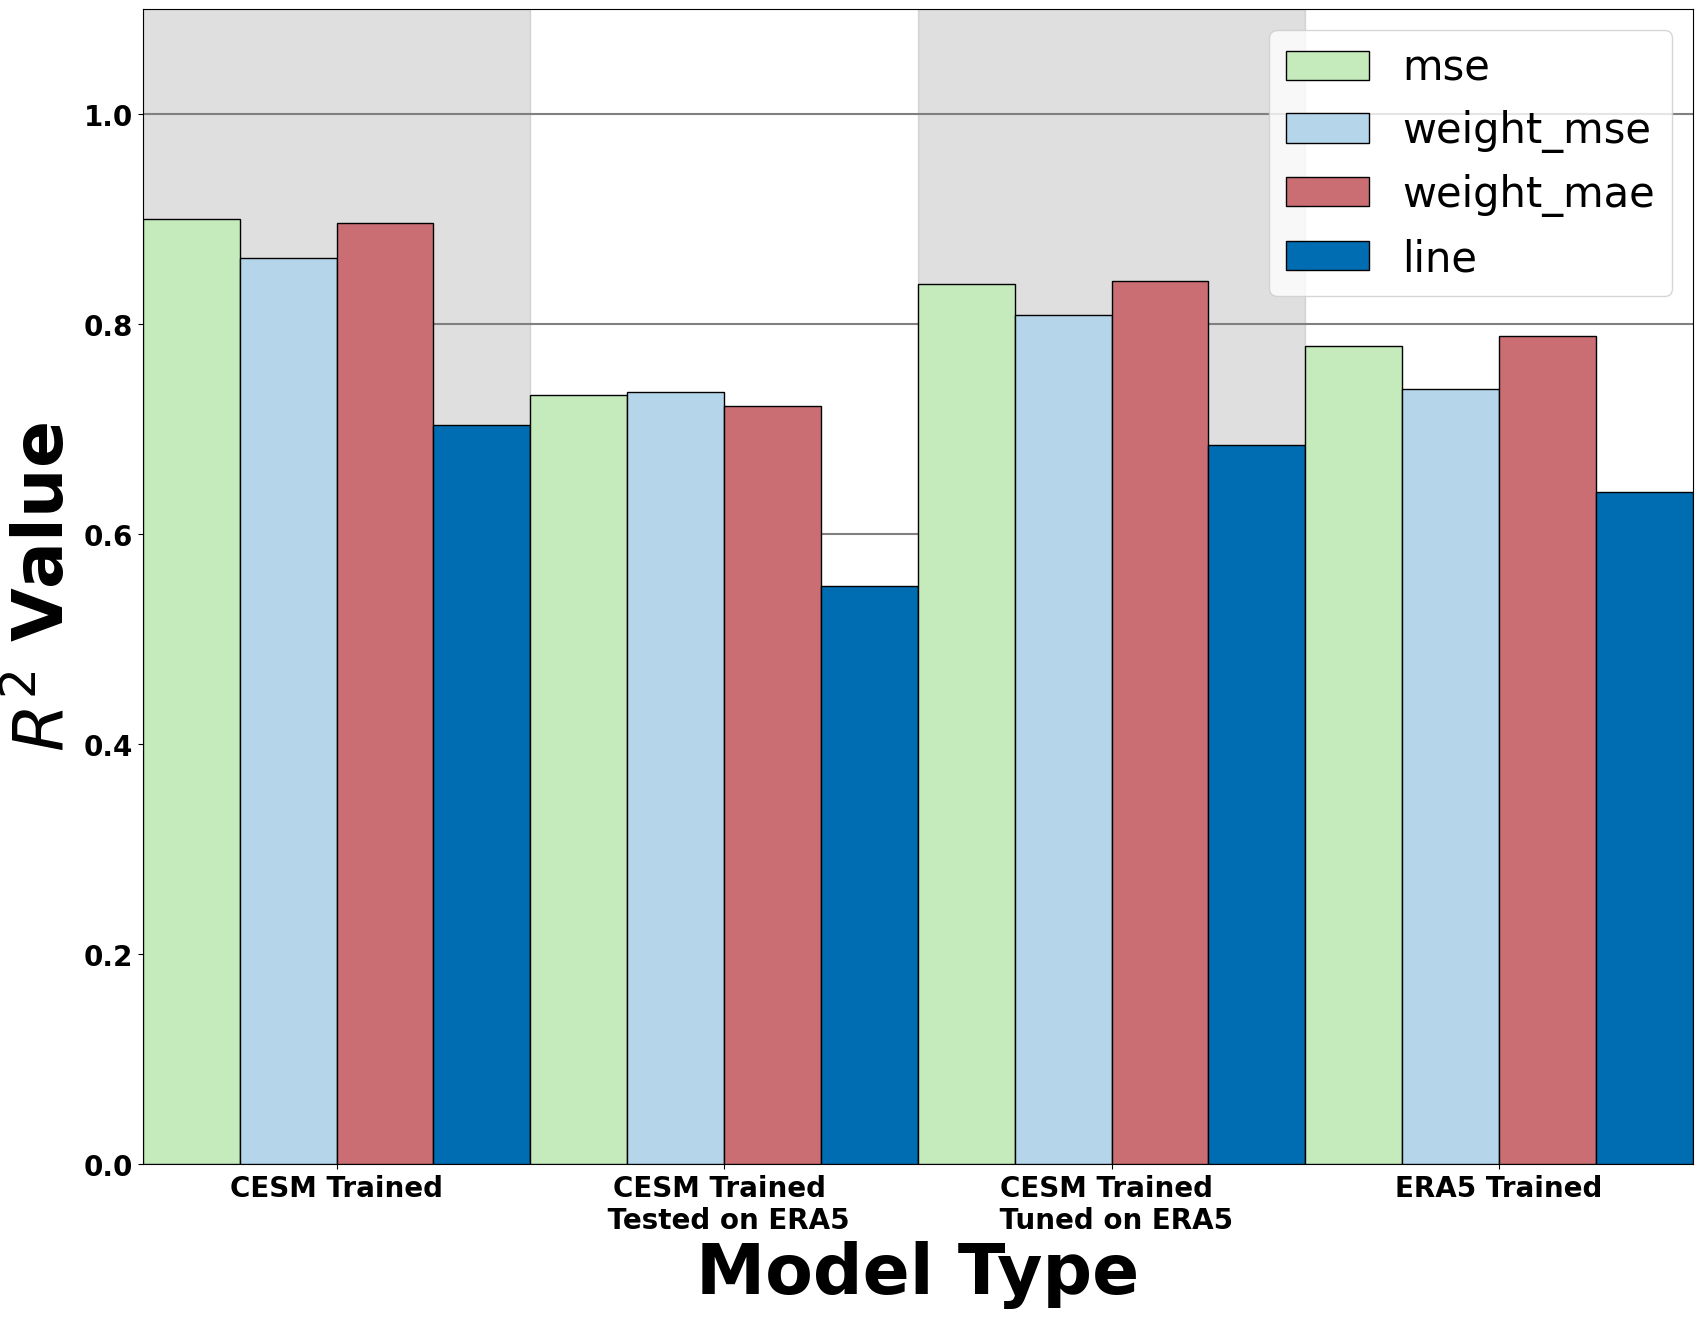

In [14]:
loc = 'ca'
sub_df = df[(df['location'] == loc)].copy()
fig = plt.figure(figsize=(20,15))
colors = ['#c5eabc', '#b5d6ea', '#ca6e74', '#006db3', '#a51017']

for rid, direct in enumerate(dirs):
    
    for did, model_type in enumerate(model_types):
        cur_df = sub_df[((sub_df['directory'] == direct) & (sub_df['dataset'] == datasets[rid])
                         & (sub_df['model type'] == model_type))].copy()
        
        plt.bar(rid + ((did)*0.25), cur_df['r2'].values[0], width=0.25, color = colors[did], edgecolor='k', zorder=10)
        
plt.xticks(np.arange(0.375,4,1), ['CESM Trained', 'CESM Trained \n Tested on ERA5',
                                  'CESM Trained \n Tuned on ERA5', 'ERA5 Trained'],
           fontsize=20, fontweight='bold')
plt.xlabel('Model Type', fontsize=50).set_weight('bold')
plt.yticks(fontsize=20, fontweight='bold')
plt.ylabel(f'$R^2$ Value', fontsize=50).set_weight('bold')

plt.legend(colors, labels=model_types, fontsize=30)

plt.axhline(y = 1, color = 'grey', ls='-')
plt.axhline(y = 0.8, color = 'grey', ls='-')
plt.axhline(y = 0.6, color = 'grey', ls='-')

plt.axvspan(-0.125, 0.875, color='grey', alpha=0.25)
plt.axvspan(2-0.125, 2.875, color='grey', alpha=0.25)
    
plt.xlim(-0.125,3.875)
plt.ylim(0,1.1)

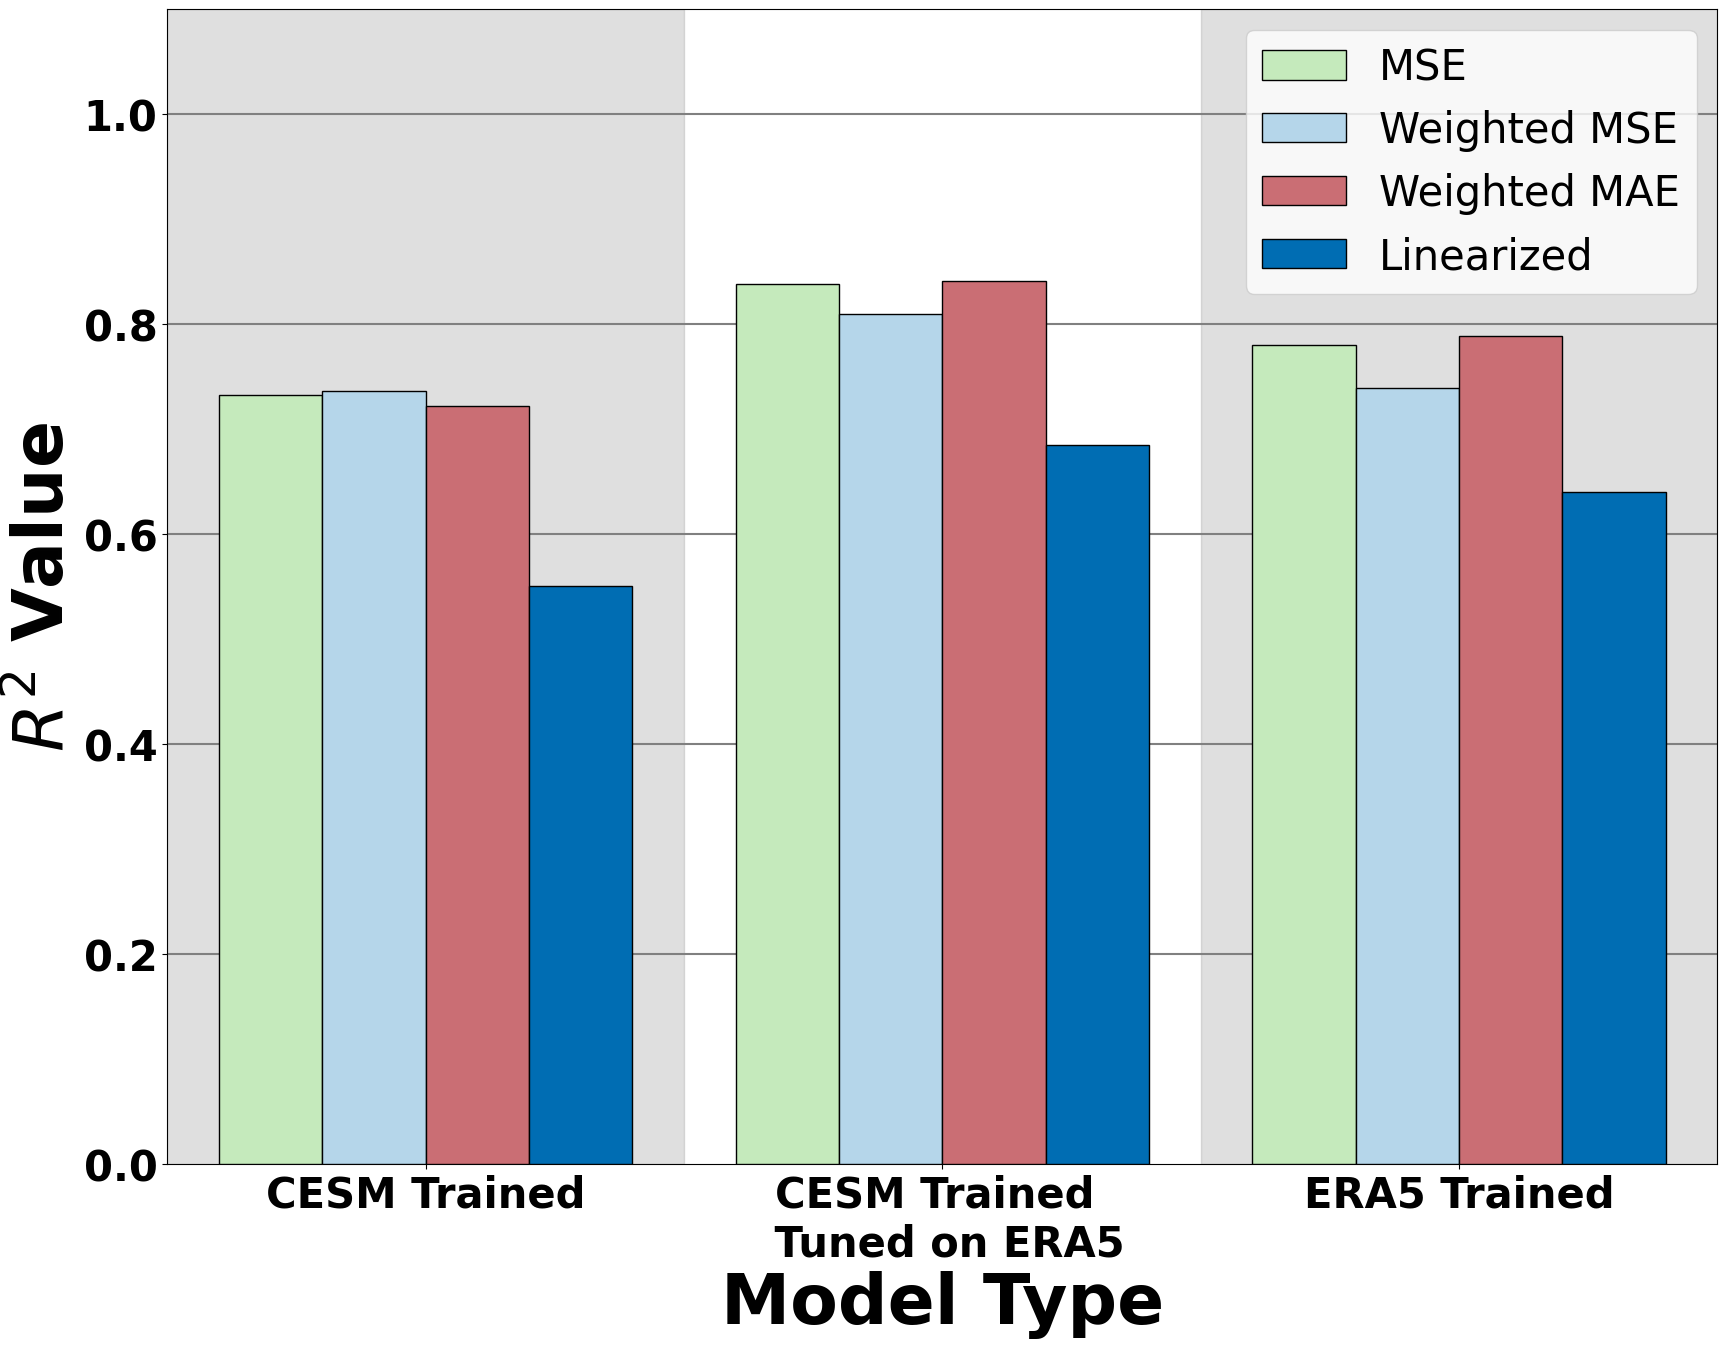

In [18]:
loc = 'ca'
sub_df = df[(df['location'] == loc)].copy()
fig = plt.figure(figsize=(20,15))
colors = ['#c5eabc', '#b5d6ea', '#ca6e74', '#006db3', '#a51017']
label_types = ['MSE', 'Weighted MSE', 'Weighted MAE', 'Linearized']

for rid, direct in enumerate(dirs[1:]):
    
    for did, model_type in enumerate(model_types):
        cur_df = sub_df[((sub_df['directory'] == direct) & (sub_df['dataset'] == datasets[rid+1])
                         & (sub_df['model type'] == model_type))].copy()
        
        plt.bar(rid + ((did)*0.2), cur_df['r2'].values[0], width=0.2, color = colors[did], edgecolor='k', zorder=10)
        
plt.xticks(np.arange(0.3,3,1), ['CESM Trained', 'CESM Trained \n Tuned on ERA5', 'ERA5 Trained'],
           fontsize=30, fontweight='bold')

plt.xlabel('Model Training Settings', fontsize=50).set_weight('bold')
plt.yticks(fontsize=30, fontweight='bold')
plt.ylabel(f'$R^2$ Value', fontsize=50).set_weight('bold')

plt.legend(colors, labels=label_types, fontsize=30)

plt.axhline(y = 1, color = 'grey', ls='-')
plt.axhline(y = 0.8, color = 'grey', ls='-')
plt.axhline(y = 0.6, color = 'grey', ls='-')
plt.axhline(y = 0.4, color = 'grey', ls='-')
plt.axhline(y = 0.2, color = 'grey', ls='-')

plt.axvspan(-0.2, 0.8, color='grey', alpha=0.25)
plt.axvspan(1.8, 2.8, color='grey', alpha=0.25)
    
plt.xlim(-0.2,2.8)
plt.ylim(0,1.1)

plt.savefig('model_type_and_loss_function.png', format='png', dpi=500, bbox_inches='tight')

(0.0, 1.1)

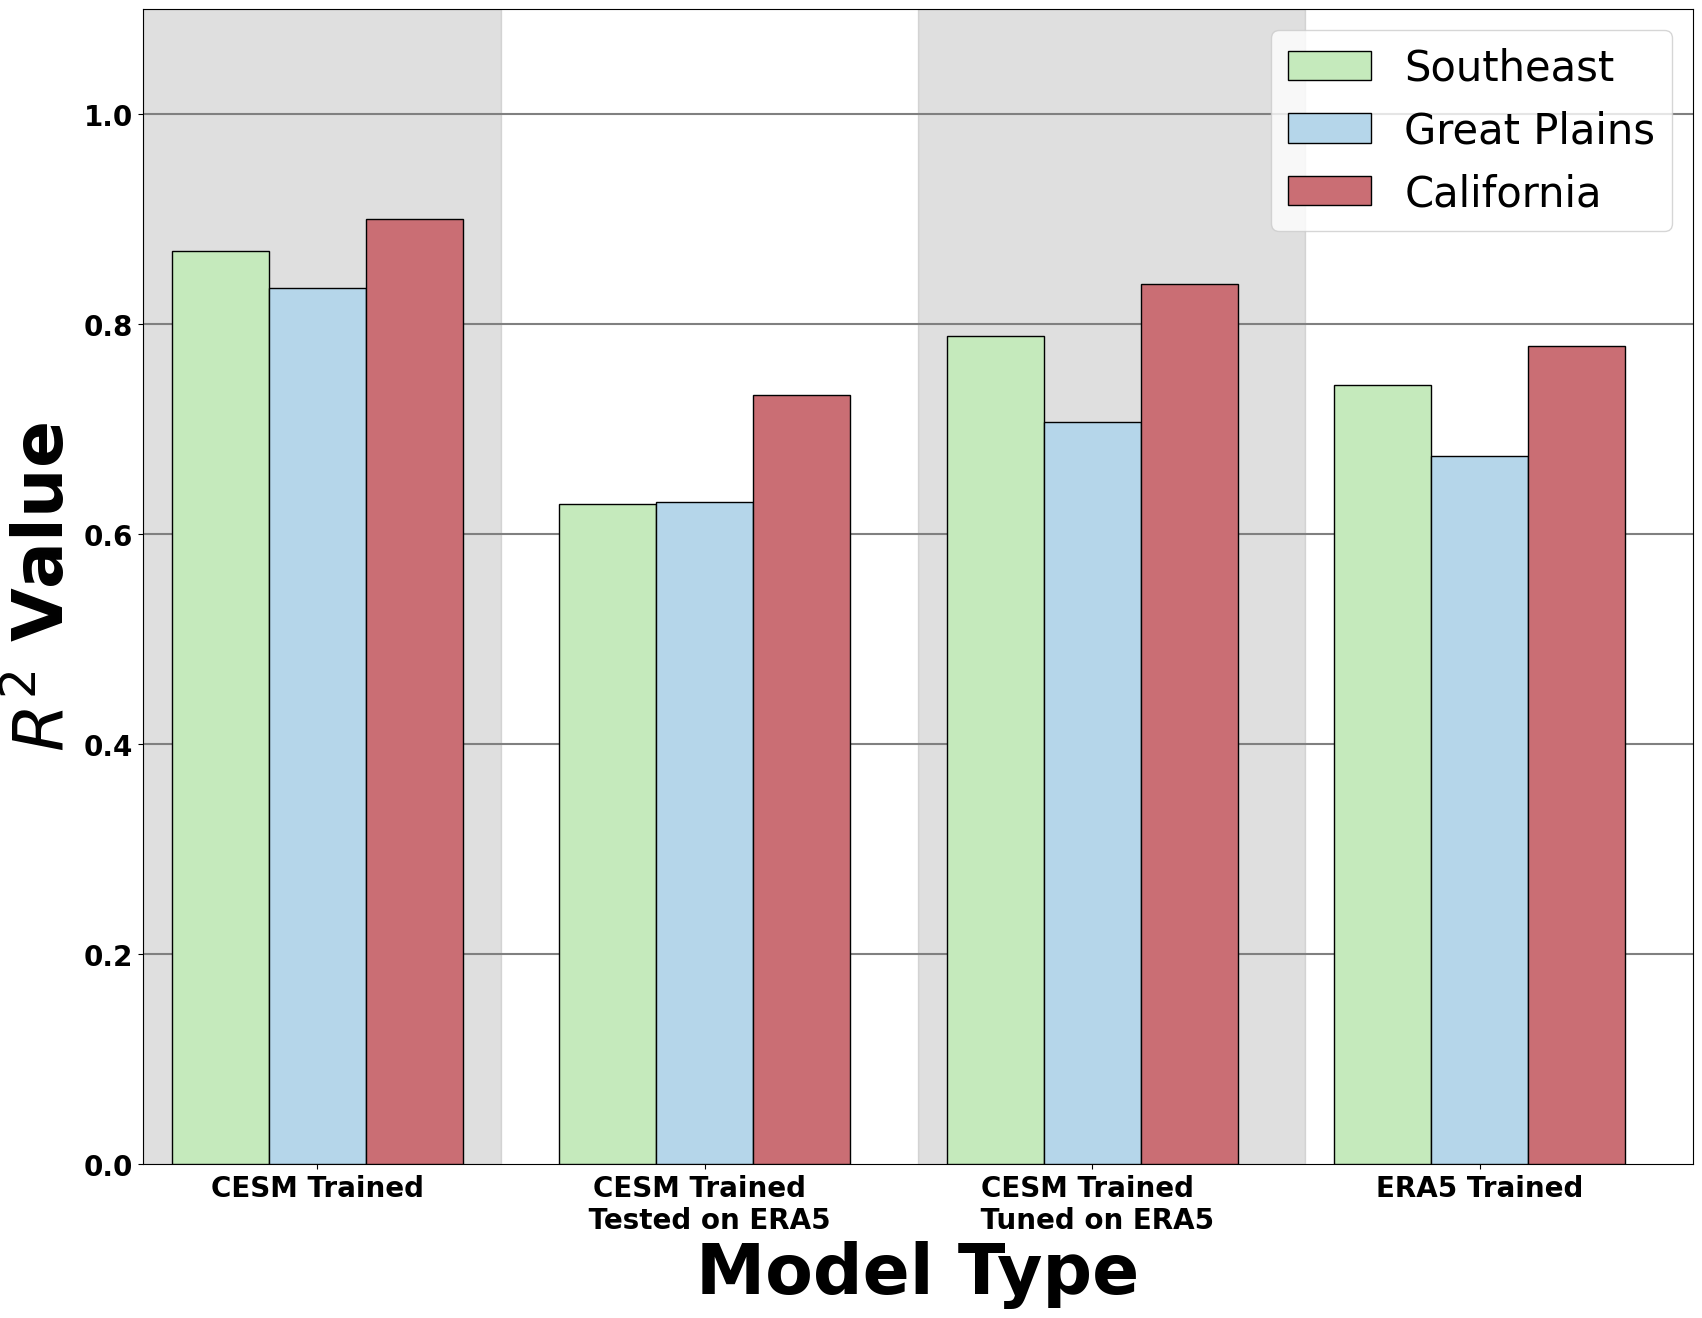

In [135]:
model_type = 'mse'
sub_df = df[(df['model type'] == model_type)].copy()
fig = plt.figure(figsize=(20,15))
location_labels = ['Southeast', 'Great Plains', 'California']

for rid, direct in enumerate(dirs):
    for did, loc in enumerate(locs):
        cur_df = sub_df[((sub_df['directory'] == direct) & (sub_df['dataset'] == datasets[rid])
                         & (sub_df['location'] == loc))].copy()
        
        plt.bar(rid + ((did)*0.25), cur_df['r2'].values[0], width=0.25, color = colors[did], edgecolor='k', zorder=10)
        
plt.xticks(np.arange(0.25, 4, 1), ['CESM Trained', 'CESM Trained \n Tested on ERA5', 'CESM Trained \n Tuned on ERA5', 'ERA5 Trained'],
           fontsize=20, fontweight='bold')
plt.xlabel('Model Type', fontsize=50).set_weight('bold')
plt.yticks(fontsize=20, fontweight='bold')
plt.ylabel(f'$R^2$ Value', fontsize=50).set_weight('bold')

plt.legend(colors, labels=location_labels, fontsize=30)

plt.axhline(y = 1, color = 'grey', ls='-')
plt.axhline(y = 0.8, color = 'grey', ls='-')
plt.axhline(y = 0.6, color = 'grey', ls='-')
plt.axhline(y = 0.4, color = 'grey', ls='-')
plt.axhline(y = 0.2, color = 'grey', ls='-')

plt.axvspan(-0.2, 0.725, color='grey', alpha=0.25)
plt.axvspan(1.8, 2.8, color='grey', alpha=0.25)
    
plt.xlim(-0.2,3.8)
plt.ylim(0,1.1)

In [ ]:
##

In [25]:
model_types = ['mse', 'weight_mse', 'weight_mae', 'line']
loc='ca'


for model_type in model_types:

    model_list = glob.glob(f'{base_path}/Data/ERA5/models/trans_learn/post/{loc}_max_precip_{model_type}_model*')
    
    locals()[f'preds_{model_type}'] = []

    for num3, model_path in enumerate(model_list):

        if model_type == 'weight_mse' or model_type == 'line':
            model = load_model(f"{model_path}", compile=False)

        else:
            model = load_model(f"{model_path}", safe_mode=False)
            
        y_pred = model.predict(x_test_era5, verbose=0).flatten()
        locals()[f'preds_{model_type}'].append(y_pred)


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

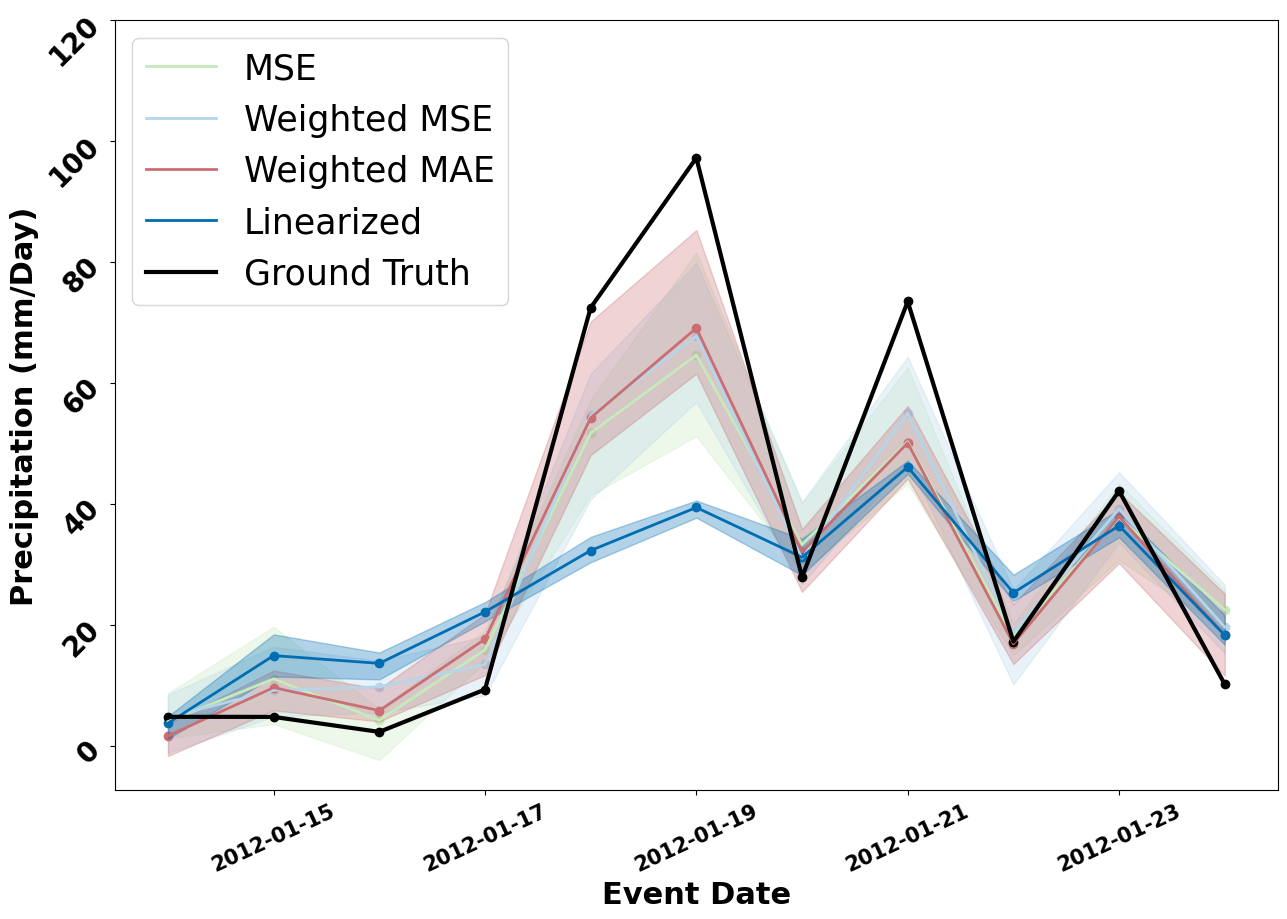

In [75]:
fig = plt.figure(figsize=(15,10))
event = 3

df = locals()[f'df_{loc}_era5'][8000:].reset_index()
idx2 = df['Maximum Precipitation'].nlargest(event).iloc[-1]
index = df[df['Maximum Precipitation'] == idx2].index[0]

for num3, model_type in enumerate(model_types):
    mean = np.mean(np.array(locals()[f'preds_{model_type}']),axis=0)
    mini = np.min(np.array(locals()[f'preds_{model_type}']),axis=0)
    maxi = np.max(np.array(locals()[f'preds_{model_type}']),axis=0)
    df_sub = df.iloc[max(index-5, 0): min(index+6, len(df))]
    
    plt.plot(df_sub['Datetimes'].values, mean[df_sub['index'].values-8000], color=colors[num3], label=label_types[num3], lw=2)
    plt.scatter(df_sub['Datetimes'].values, mean[df_sub['index'].values-8000], color=colors[num3], label=None)
    plt.fill_between(df_sub['Datetimes'].values, y1=mini[df_sub['index'].values-8000], y2=maxi[df_sub['index'].values-8000],
                     color=colors[num3], alpha=0.3, label=None)
    
    if num3 == 3:
        plt.plot(df_sub['Datetimes'].values, df_sub['Maximum Precipitation'].values, color='k', label='Ground Truth', lw=3)
        plt.scatter(df_sub['Datetimes'].values, df_sub['Maximum Precipitation'].values, color='k', label=None)
        
    plt.xlabel('Event Date', fontsize=22).set_weight('bold')
    plt.ylabel('Precipitation (mm/Day)', fontsize=22).set_weight('bold')
    plt.yticks(np.arange(0, 130, 20), np.arange(0, 130, 20), fontsize=20, rotation=45, fontweight='bold')
    plt.xticks(df_sub['Datetimes'].values[np.arange(1, 11, 2)], df_sub['Datetimes'].values[np.arange(1, 11, 2)],
               fontsize=15, rotation=25, fontweight='bold')
    plt.legend(fontsize=25)
    
plt.savefig(f'{loc}_precip_series.png', format='png', dpi=500, bbox_inches='tight')

In [13]:
locs = ['se', 'gp', 'ca']
dirs = ['pre', 'pre', 'post', 'brute']
datasets = ['cesm', 'era5', 'era5', 'era5']
model_types = ['mse', 'weight_mse', 'weight_mae', 'line']

for num1, direct in enumerate(dirs):
    
    for loc in locs:
        
        for model_type in model_types:
            
            model_list = glob.glob(f'{base_path}/Data/ERA5/models/trans_learn/{direct}/{loc}_max_precip_{model_type}_model*')
            locals()[f'rs_{loc}_{model_type}_{direct}_{datasets[num1]}'] = []
            
            for model_path in model_list:
                
                if model_type == 'weight_mse' or model_type == 'line':
                    model = load_model(f"{model_path}", compile=False)
                    
                else:
                    model = load_model(f"{model_path}", safe_mode=False)
                    
                y_pred = model.predict(locals()[f'x_test_{datasets[num1]}'])
                locals()[f'rs_{loc}_{model_type}_{direct}_{datasets[num1]}'].append(r2_score(locals()[f'y_{loc}_{datasets[num1]}_test'], y_pred))
                    

I0000 00:00:1764554137.596623  268157 service.cc:146] XLA service 0x7f256c008500 initialized for platform Host (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1764554137.596671  268157 service.cc:154]   StreamExecutor device (0): Host, Default Version


  5/708 ━━━━━━━━━━━━━━━━━━━━ 11s 16ms/step  

I0000 00:00:1764554137.976988  268157 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


708/708 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 14s 19ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 13s 19ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 14s 18ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 13s 18ms/step
708/708 ━━━━━━━━━━━━━━━━━━━━ 13

In [52]:
import matplotlib.patches as mpatches
import matplotlib.lines as mlines

#create custom boxplot
patch1 = mpatches.Patch(color=colors[0], label='Southeast')
patch2 = mpatches.Patch(color=colors[1], label='Great Plains')
patch3 = mpatches.Patch(color=colors[2], label='California')

handles = [patch1, patch2, patch3]

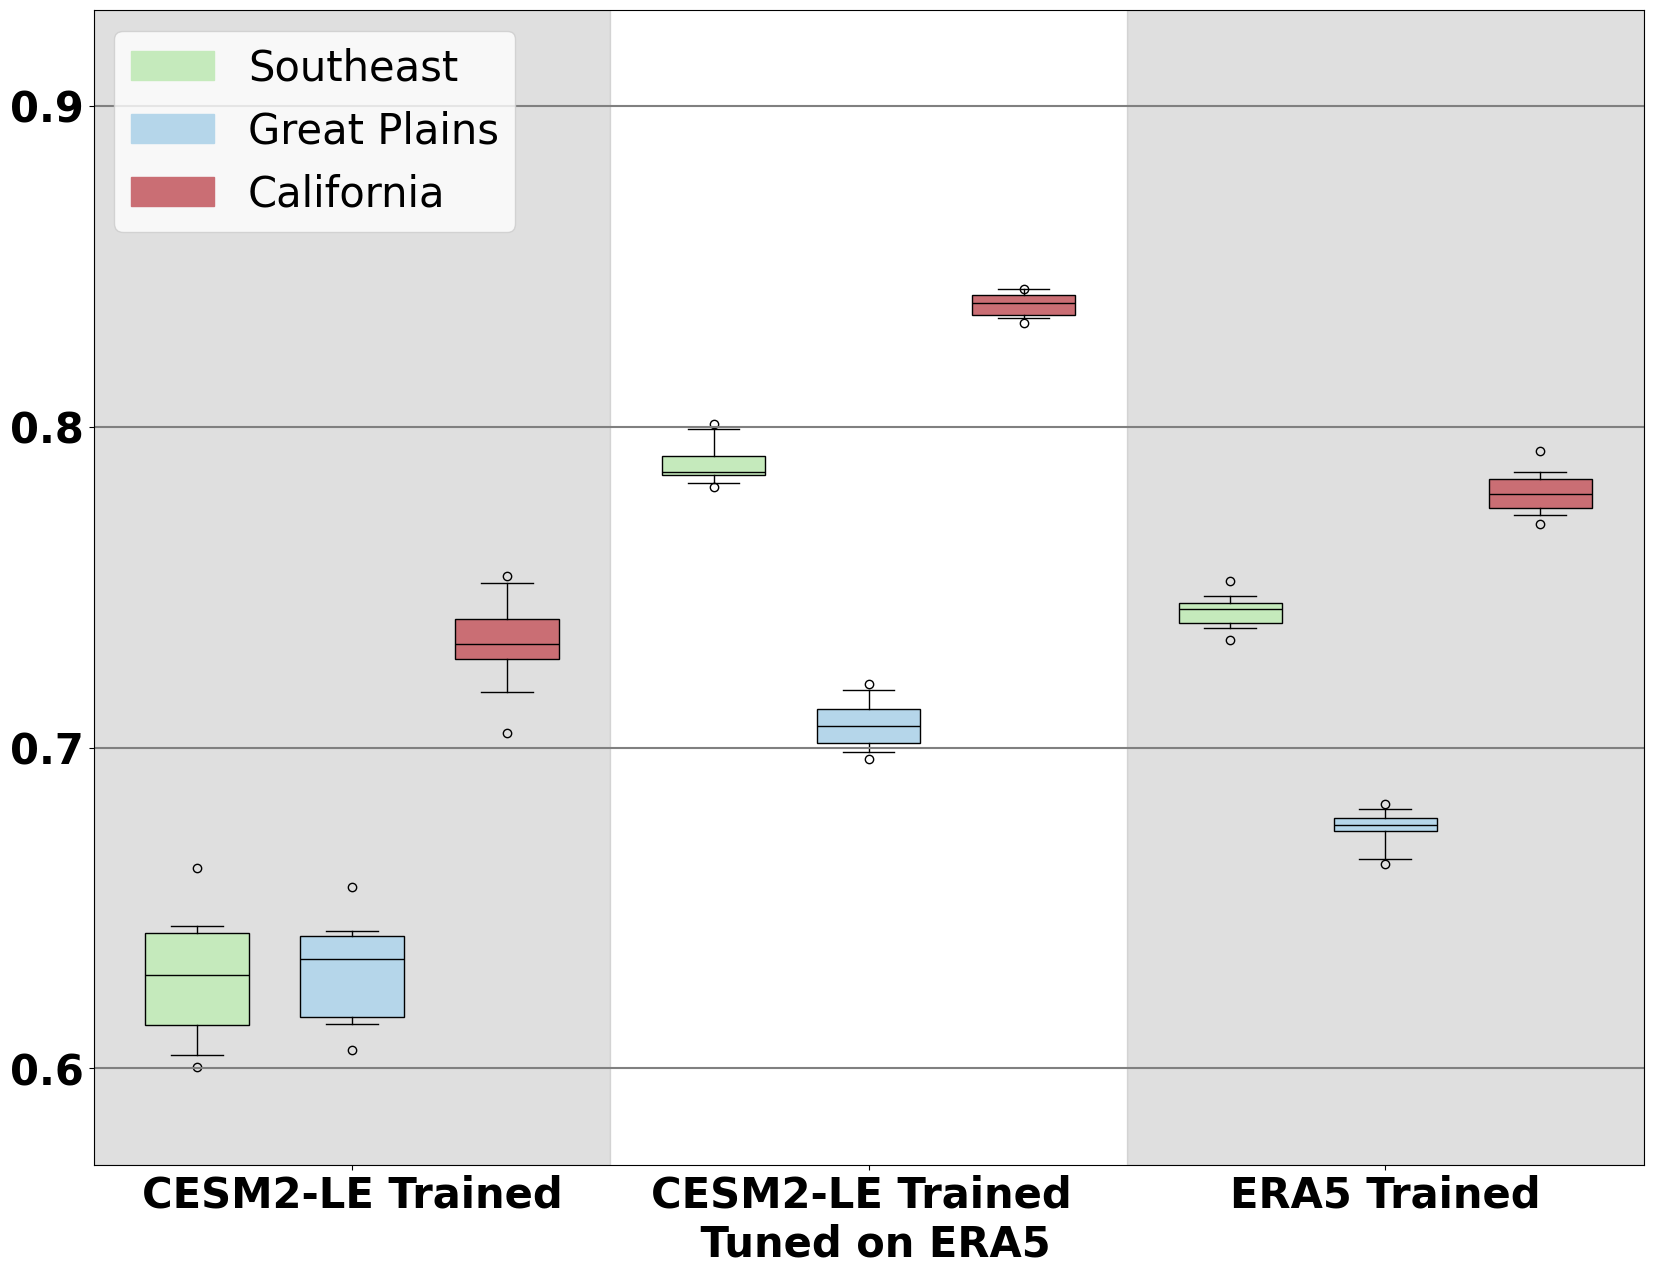

In [64]:
fig = plt.figure(figsize=(20, 15))
colors = ['#c5eabc', '#b5d6ea', '#ca6e74', '#006db3', '#a51017']

for num1, direct in enumerate(dirs[1:]):

    bplot = plt.boxplot(
        [locals()[f'rs_se_mse_{direct}_{datasets[num1+1]}'], locals()[f'rs_gp_mse_{direct}_{datasets[num1+1]}'],
         locals()[f'rs_ca_mse_{direct}_{datasets[num1+1]}']], positions=[num1 - 0.3, num1, num1 + 0.3],
        whis=[5, 95], widths=0.2, patch_artist=True)

    # ---- color boxes ----
    for patch, color in zip(bplot['boxes'], colors[:3]):  # only 3 boxplots → only color 3
        patch.set_facecolor(color)

    # ---- median + mean styling ----
    plt.setp(bplot['medians'], color='black')
    for m in bplot['means']:
        m.set_color('black')

# ---- spanning boxes ----
plt.axvspan(-0.5, 0.5, color='grey', alpha=0.25)
plt.axvspan(1.5, 2.5, color='grey', alpha=0.25)
plt.axhline(y = 0.8, color = 'grey', ls='-')
plt.axhline(y = 0.7, color = 'grey', ls='-')
plt.axhline(y = 0.6, color = 'grey', ls='-')
plt.axhline(y = 0.9, color = 'grey', ls='-')
plt.xlim(-0.5, 2.5)
plt.ylim(0.57, 0.93)

plt.xticks(np.arange(3), ['CESM2-LE Trained', 'CESM2-LE Trained \n Tuned on ERA5', 'ERA5 Trained'],
           fontsize=30, fontweight='bold')
plt.yticks(np.arange(0.6,0.91,0.1), [0.60, 0.70, 0.80, 0.90], fontsize=30, fontweight='bold')
plt.legend(handles=handles, loc='upper left',fontsize=30)

plt.savefig('boxplot.png', format='png', dpi=500, bbox_inches='tight')